In [1]:
"""Utility for fetching Polymarket probability time series."""

import re
from datetime import datetime, timezone
from typing import Iterable
from pathlib import Path
import pandas as pd
import requests
import os, json
from py_clob_client.client import ClobClient

In [2]:
host: str = "https://clob.polymarket.com"
key: str = "0x17d0a712b5593a0a753f84df5f659f0e1a7adf208bb659b9dc7a33a333e855d9" #This is your Private Key. Export from https://reveal.magic.link/polymarket or from your Web3 Application
chain_id: int = 137 #No need to adjust this
POLYMARKET_PROXY_ADDRESS: str = '0xe99c8f0f9ee37f005c2888fd481d2443c86b3868' #This is the address you deposit/send USDC to to FUND your Polymarket account.

#Select from the following 3 initialization options to matches your login method, and remove any unused lines so only one client is initialized.


### Initialization of a client using a Polymarket Proxy associated with an Email/Magic account. If you login with your email use this example.
client = ClobClient(host, key=key, chain_id=chain_id, signature_type=1, funder=POLYMARKET_PROXY_ADDRESS)


In [3]:
def token_finder(slug):
    next_cursor, found = "", None

    while next_cursor != "LTE=":                          # END_CURSOR sentinel
        page = client.get_markets(next_cursor=next_cursor)
        next_cursor = page["next_cursor"]
        for m in page["data"]:
            if m["market_slug"] == slug:                  # match!
                found = m
                break
        if found:
            break

    tokens = {t["outcome"]: t["token_id"] for t in found["tokens"]}
    return tokens

In [4]:
def url_token_finder(url):
    m = re.match(r'https://polymarket.com/event/([^/]+)', url)
    if not m:
        raise ValueError("Invalid Polymarket market URL")
    slug = m.group(1)
    tokens = token_finder(slug)
    if not tokens:
        raise ValueError("Market not found for the given URL")
    return tokens

In [5]:
def price_history(market_id):
    url = "https://clob.polymarket.com/prices-history"

    response_1 = requests.get(url, params={
        "market": list(market_id.values())[0],
        "interval": 'max',
        "fidelity": "0.25"
    })
    response_2 = requests.get(url, params={
        "market": list(market_id.values())[1],
        "interval": 'max',
        "fidelity": "0.25"
    })    

    return response_1.json(), response_2.json()

In [6]:
def _series_from_history_obj(obj):
    data = obj.get('history') if isinstance(obj, dict) and 'history' in obj else obj
    if data is None:
        return pd.Series(dtype=float)
    df = pd.DataFrame(data)
    # Infer columns
    tcol = 't' if 't' in df.columns else ('timestamp' if 'timestamp' in df.columns else ('time' if 'time' in df.columns else None))
    vcol = 'p' if 'p' in df.columns else ('price' if 'price' in df.columns else ('close' if 'close' in df.columns else None))
    if tcol is None or vcol is None or df.empty:
        return pd.Series(dtype=float)
    # Parse timestamp (seconds vs ms)
    ts_vals = df[tcol].values
    unit = 's'
    try:
        mx = pd.to_numeric(df[tcol], errors='coerce').max()
        if pd.notna(mx) and mx > 10**12:
            unit = 'ms'
    except Exception:
        pass
    idx = pd.to_datetime(df[tcol], unit=unit, errors='coerce')
    s = pd.Series(pd.to_numeric(df[vcol], errors='coerce').values, index=idx)
    return s.dropna().sort_index()

In [7]:

def plot_price_history_series(market_tokens: dict, start: str = None, end: str = None, sample_rate: str = None, labels=None):
    """
    Calls the existing price_history(market_tokens) and plots the returned history.
    - start/end: optional ISO datetime strings to window the plot
    - sample_rate: optional pandas offset alias for resampling (e.g., '5min', '1H')
    - labels: optional list of labels for the lines (defaults to market_tokens keys)
    Returns the created matplotlib Figure.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # Call user-defined price_history()
    resp = price_history(market_tokens)
    if isinstance(resp, (list, tuple)):
        histories = list(resp)
    else:
        histories = [resp]

    series_list = [_series_from_history_obj(h) for h in histories]

    # Window + resample
    out_series = []
    for s in series_list:
        if s.empty:
            out_series.append(s)
            continue
        if start is not None:
            s = s[s.index >= pd.to_datetime(start)]
        if end is not None:
            s = s[s.index <= pd.to_datetime(end)]
        if sample_rate:
            s = s.resample(sample_rate).last().ffill()
        out_series.append(s)

    # Labels
    if labels is None and isinstance(market_tokens, dict):
        labels = list(market_tokens.keys())
    if labels is None or len(labels) < len(out_series):
        labels = [f'series {i+1}' for i in range(len(out_series))]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    for s, lab in zip(out_series, labels):
        if s.empty:
            continue
        ax.plot(s.index, s.values, label=lab)
    ax.set_xlabel('Time')
    ax.set_ylabel('Price')
    ax.set_title('Polymarket Price History')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    fig.autofmt_xdate()


In [8]:
def plot_url(url):
    plot_price_history_series(url_token_finder(url))

In [9]:
def save_url_data(url):
    """
    Fetch tokens and price history for a Polymarket event URL,
    then save each outcome's history as JSON (and CSV) under
    data/polymarket/<slug>/<Outcome>.json (and .csv).

    Returns: dict outcome->saved path(s).
    """


    tokens = url_token_finder(url)
    a, b = price_history(tokens)

    # Derive folder name from URL slug
    m = re.match(r'https://polymarket.com/event/([^/]+)', url)
    if not m:
        raise ValueError("Invalid Polymarket market URL")
    slug = m.group(1)
    out_dir = Path('data') / 'polymarket' / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    names = list(tokens.keys())
    responses = [a, b]
    saved = {}
    for name, resp in zip(names, responses):
        safe = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in name).strip('_') or 'series'
        json_path = out_dir / f'{safe}.json'
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(resp, f, ensure_ascii=False, indent=2)
        saved[name] = str(json_path)

        # Also save a CSV of the history if present
        if isinstance(resp, dict) and 'history' in resp and isinstance(resp['history'], list):
            df = pd.DataFrame(resp['history'])
            if not df.empty and 't' in df.columns and 'p' in df.columns:
                unit = 'ms' if pd.to_numeric(df['t'], errors='coerce').max() > 10**12 else 's'
                df['time'] = pd.to_datetime(df['t'], unit=unit)
                df.rename(columns={'p': 'price'}, inplace=True)
                csv_path = out_dir / f'{safe}.csv'
                df[['time', 'price']].to_csv(csv_path, index=False)
                saved[name + '_csv'] = str(csv_path)

    return saved


In [10]:
def plot_csv(folder_path):
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    folder = Path(folder_path)
    if not folder.is_dir():
        raise ValueError("Provided path is not a directory")

    csv_files = list(folder.glob('*.csv'))
    if not csv_files:
        raise ValueError("No CSV files found in the directory")

    plt.figure(figsize=(10, 4))
    for csv_file in csv_files:
        df = pd.read_csv(csv_file, parse_dates=['time'])
        if 'time' not in df.columns or 'price' not in df.columns:
            continue
        plt.plot(df['time'], df['price'], label=csv_file.stem)

    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title('Polymarket Price History from CSVs')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [11]:
urls = [
  "https://polymarket.com/event/us-open-jannik-sinner-vs-carlos-alcaraz",
  "https://polymarket.com/event/us-open-aryna-sabalenka-vs-amanda-anisimova-2025-09-06",
  "https://polymarket.com/event/us-open-novak-djokovic-vs-carlos-alcaraz-2025-09-05",
  "https://polymarket.com/event/us-open-jiri-lehecka-vs-carlos-alcaraz-2025-09-02",
  "https://polymarket.com/event/us-open-luciano-darderi-vs-carlos-alcaraz-2025-08-29",
  "https://polymarket.com/event/us-open-amanda-anisimova-vs-iga-swiatek-2025-09-03",
  "https://polymarket.com/event/us-open-aryna-sabalenka-vs-jessica-pegula-2025-09-04",
  "https://polymarket.com/event/us-open-karolina-muchova-vs-naomi-osaka-2025-09-03",
  "https://polymarket.com/event/us-open-novak-djokovic-vs-taylor-fritz-2025-09-02",
  "https://polymarket.com/event/us-open-novak-djokovic-vs-jan-lennard-struff-2025-08-31",
  "https://polymarket.com/event/us-open-tomas-machac-vs-taylor-fritz-2025-08-31",
  "https://polymarket.com/event/us-open-jannik-sinner-vs-alexander-bublik-2025-09-01",
  "https://polymarket.com/event/us-open-jerome-kym-vs-taylor-fritz-2025-08-29",
  "https://polymarket.com/event/us-open-karen-khachanov-vs-kamil-majchrzak-2025-08-28",
  "https://polymarket.com/event/us-open-valentin-royer-vs-denis-shapovalov-2025-08-28",
  "https://polymarket.com/event/us-open-leandro-riedi-vs-francisco-cerundolo-2025-08-28",
  "https://polymarket.com/event/us-open-alexander-bublik-vs-tommy-paul-2025-08-30",
  "https://polymarket.com/event/us-open-aryna-sabalenka-vs-marketa-vondrousova-2025-09-02",
  "https://polymarket.com/event/us-open-naomi-osaka-vs-amanda-anisimova-2025-09-04",
  "https://polymarket.com/event/us-open-alexander-zverev-vs-alejandro-tabilo-2025-08-25",
  "https://polymarket.com/event/us-open-alexander-shevchenko-vs-alejandro-davidovich-fokina-2025-08-24",
  "https://polymarket.com/event/us-open-novak-djokovic-vs-cameron-norrie-2025-08-29",
  "https://polymarket.com/event/us-open-ekaterina-alexandrova-vs-iga-swiatek-2025-09-01",
  "https://polymarket.com/event/us-open-karen-khachanov-vs-nishesh-basavareddy-2025-08-25/us-open-karen-khachanov-vs-nishesh-basavareddy-2025-08-25"
]


In [12]:
for i in urls:
    save_url_data(i)

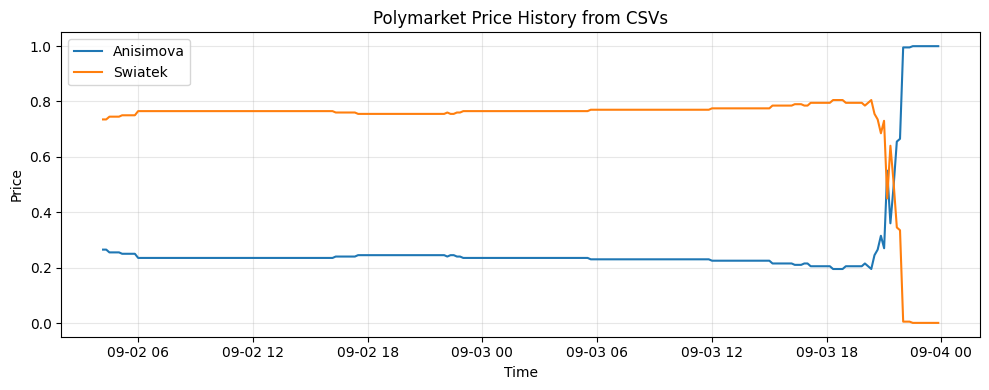

In [13]:
plot_csv('data/polymarket/us-open-amanda-anisimova-vs-iga-swiatek-2025-09-03')
